## 3. INSIGHTS Y SEGMENTACIÓN ACCIONABLE

**Objetivo:** traducir el análisis EDA en decisiones concretas de marketing y segmentación de audiencias.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Añadir el path para importar utils
sys.path.append('..')
from scripts.utils import detectar_tematica_asunto

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. CARGA DE DATOS
df = pd.read_csv("../data/processed/data_limpia.csv")

# 2. CÁLCULO DE MÉTRICAS DE NEGOCIO
# Engagement Score: Ponderación de Apertura (30%) y Clics (70%)
df['engagement_score'] = (df['trackable_open_rate'] * 0.3) + (df['click_rate'] * 0.7)

### 1. Segmentación por Rendimiento

Primero filtramos campañas con bajo volumen de envío para evitar sesgos en los KPIs, ya que pequeñas muestras generan métricas poco fiables.”

In [71]:
print("Antes:", len(df))

df = df[df["sent"] >= 50].copy()

print("Después:", len(df))

Antes: 54
Después: 44


In [83]:
# Definimos campañas top de forma dinámica, considerando como top aquellas con click_rate por encima del percentil 75:

open_p75 = df['trackable_open_rate'].quantile(0.75)
click_p75 = df['click_rate'].quantile(0.75)
    
df['top_campaign'] = (
    (df['trackable_open_rate'] >= open_p75) &
    (df['click_rate'] >= click_p75)
).astype(int)

df['top_campaign'].value_counts()

top_campaign
0    34
1    10
Name: count, dtype: int64

He definido campañas top usando percentiles, lo que adapta el análisis al comportamiento real de los datos y evita umbrales arbitrarios.

Después categorizamos las campañas en base a su éxito relativo (Open Rate y Click Rate).

In [82]:
def segmentar_rendimiento(row):
    if row['trackable_open_rate'] >= open_p75 and row['click_rate'] >= click_p75:
        return 'Top Performance'
    elif row['trackable_open_rate'] >= open_p75:
        return 'Buen Alcance'
    elif row['click_rate'] >= click_p75:
        return 'Alto Interés'
    else:
        return 'Bajo Rendimiento' 

df['segmento_rendimiento'] = df.apply(segmentar_rendimiento, axis=1)
df['segmento_rendimiento'].value_counts()

segmento_rendimiento
Bajo Rendimiento    32
Top Performance     10
Buen Alcance         1
Alto Interés         1
Name: count, dtype: int64

<Axes: xlabel='segmento_rendimiento'>

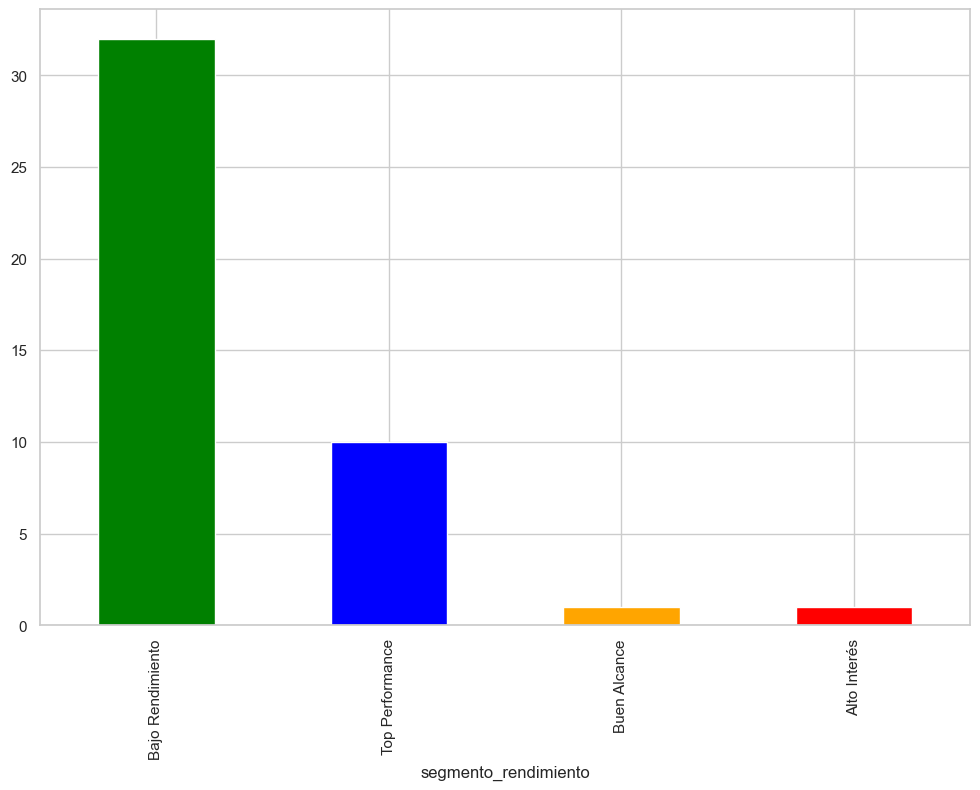

In [73]:
df['segmento_rendimiento'].value_counts().plot(kind='bar', color=['green', 'blue', 'orange', 'red'])

In [86]:
comparacion = df.groupby('segmento_rendimiento')[['trackable_open_rate', 'click_rate', 'engagement_score']].mean().sort_values('engagement_score', ascending=False)
display(comparacion)

### 2. Eficiencia por Volumen de Envío
¿Estamos quemando la lista? Analizamos si el aumento de envíos penaliza la tasa de apertura.

In [87]:
corr = df['sent'].corr(df['trackable_open_rate'])
plt.figure(figsize=(10, 6))
sns.regplot(x='sent', y='trackable_open_rate', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlación entre Volumen y Open Rate: {corr:.2f}')
plt.xlabel('Volumen de Envío (Sent)')
plt.ylabel('Open Rate (%)')
plt.show()

if corr < -0.4:
    print("⚠️ Alerta: Existe una correlación negativa fuerte. Las listas grandes abren menos.")
else:
    print("✅ El volumen de envío no está afectando significativamente a la apertura.")

## 📊 Insights clave sobre rendimiento de campañas

### 🧠 Open rate ≠ Click rate
- Un alto porcentaje de apertura no garantiza una alta conversión.
- Ejemplo:
  - *Buen Alcance*: open muy alto (98.9%) pero CTR menor (26.3%)
  - *Alto Interés*: open menor (75.7%) pero CTR alto (34.0%)

👉 El asunto atrae, pero el contenido y el CTA determinan la acción.

---

### 🎯 Dos tipos de campañas efectivas

**📩 Buen Alcance**
- Alto open rate
- Menor conversión
- Posible causa: asuntos atractivos pero contenido poco accionable

**🖱️ Alto Interés**
- Menor open rate
- Alto CTR
- Posible causa: contenido relevante y CTA claro para un público específico

---

### 🏆 Top Performance = equilibrio perfecto
- Open rate muy alto (99.4%)
- CTR alto (40.8%)

👉 Las campañas más efectivas combinan:
- Asunto atractivo
- Contenido relevante
- Llamada a la acción clara

---

### ⚠️ Bajo Rendimiento
- Open rate medio (52.1%)
- CTR muy bajo (7.4%)

👉 Problemas:
- Falta de atractivo en el asunto
- Baja capacidad de conversión

---

### 🚀 Implicaciones estratégicas

- 📈 Optimizar el **alcance** → aprender de campañas con alto open rate  
- 🖱️ Mejorar la **conversión** → replicar patrones de alto CTR  
- 🏆 Maximizar rendimiento → combinar ambas estrategias (Top Performance)

---

### 💡 Conclusión
El rendimiento de una campaña depende de dos factores clave:
1. Capacidad de generar apertura (asunto)
2. Capacidad de generar acción (contenido + CTA)

👉 Las campañas más exitosas alinean ambas dimensiones.

### 3. Identificación de "Outliers de Éxito"
Detectamos campañas con un Click Rate excepcionalmente alto (> 2 desviaciones estándar sobre la media).

In [88]:
umbral_click = df['click_rate'].mean() + (2 * df['click_rate'].std())
outliers = df[df['click_rate'] > umbral_click][['subject', 'tipo_campaña', 'click_rate', 'engagement_score']].sort_values('click_rate', ascending=False)

print(f"Se han detectado {len(outliers)} outliers de éxito.")
display(outliers)

In [87]:
top_campaigns = df[df['top_campaign'] == 1].sort_values(by='click_rate', ascending=False)[['campaign_id', 'click_rate', 'trackable_open_rate', 'tipo_campaña', 'tipo_publico', 'year', 'month', 'weekday']].reset_index(drop=True)
display(top_campaigns)

,campaign_id,click_rate,trackable_open_rate,tipo_campaña,tipo_publico,year,month,weekday
0,10,59.83,100.00,invitacion,artistas,2024,10,Lunes
1,57,48.37,100.00,convocatorias,artistas,2025,1,Miércoles
2,51,43.30,100.00,convocatorias,artistas,2024,12,Miércoles
3,28,41.94,100.00,convocatorias,artistas,2024,11,Miércoles
4,69,40.79,100.00,convocatorias,artistas,2025,2,Lunes
5,75,40.34,100.00,convocatorias,artistas,2025,3,Lunes
6,80,40.00,100.00,convocatorias,artistas,2025,4,Lunes
7,81,33.90,100.00,convocatorias,artistas,2025,5,Lunes
8,90,32.82,97.95,convocatorias,artistas,2025,7,Jueves
9,92,27.04,96.43,convocatorias,artistas,2025,10,Miércoles


## 🔍 Insights sobre Top Campaigns

### 🎯 Dominancia clara de “convocatorias”
- La gran mayoría de campañas top pertenecen a la categoría **convocatorias**.
- Solo aparece una campaña de tipo “invitación”.

👉 Insight:
Las convocatorias generan **alto interés y conversión**, especialmente cuando implican acción directa (inscripción, participación, oportunidad).

---

### 👩‍🎨 Público: artistas
- El 100% de las campañas top están dirigidas a **artistas**.

👉 Insight:
El público artista muestra una **alta respuesta y engagement**, especialmente ante contenidos de oportunidad profesional.

---

### 📅 Día de envío: patrón claro

- **Lunes** → alta frecuencia en campañas top
- **Miércoles** → también relevante
- Otros días → presencia residual

👉 Insight:
Los envíos a inicio de semana funcionan mejor, posiblemente por:
- mayor atención
- planificación semanal del usuario

---

### 📈 Open rate extremadamente alto
- Casi todas las campañas tienen **open rate ≈ 100%**

👉 Insight:
- Puede indicar asuntos muy efectivos
- O posible sesgo (listas pequeñas o muy segmentadas)

⚠️ Revisión recomendada:
Validar tamaño de muestra para asegurar fiabilidad

---

### 🖱️ CTR muy alto (hasta 59%)
- CTR significativamente elevado en todas las campañas

👉 Insight:
El contenido está altamente alineado con:
- necesidades del usuario
- propuesta de valor clara
- CTA directo

---

### 📆 Evolución temporal
- Concentración en **finales de 2024 y 2025**
- Especialmente entre:
  - octubre → mayo

👉 Insight:
Puede haber:
- estacionalidad en convocatorias
- mayor actividad en ciertos periodos del año

---

## 🚀 Conclusión estratégica

Las campañas más efectivas comparten:

- 📩 Contenido de oportunidad (convocatorias)
- 🎯 Segmentación clara (artistas)
- 📅 Timing adecuado (inicio de semana)
- 🖱️ CTA directo y relevante

👉 Esto sugiere que el éxito se basa en:
**alinear contenido + público + momento + acción clara**

In [88]:
kpis_top_campaigns = (
    df.groupby(['top_campaign', 'tipo_publico', 'tipo_campaña'])[['click_rate', 'trackable_open_rate']]
    .mean()
    .sort_values(by='click_rate', ascending=False)
)

display(kpis_top_campaigns)

click_rate  trackable_open_rate
top_campaign tipo_publico  tipo_campaña                                  
1            artistas      invitacion      59.830000           100.000000
                           convocatorias   38.722222            99.375556
0            artistas      convocatorias   26.310000            81.608333
                           informativa     19.230000            95.190000
                           formacion       13.340000            88.380000
             programadores otros            5.705000            35.345000
                           promocion        5.622000            30.120000
             artistas      eventos          3.640000            67.270000
             all           ferias           2.247500            70.392500
             artistas      ferias           1.770000            59.210000
             programadores invitacion       1.120000            23.030000
                           ferias           0.720000            30.430000
             artistas      invitacion       0.560000            59.790000
             programadores formacion        0.342500            18.642500
             all           otros            0.000000            17.140000

## 🔍 Insights comparativos: Top vs No Top Campaigns

### 🎯 Las “convocatorias” dominan el rendimiento
- En campañas **top**, las convocatorias alcanzan:
  - CTR: 38.7%
  - Open rate: 99.4%
- En campañas **no top**, bajan a:
  - CTR: 26.3%
  - Open rate: 81.6%

👉 Insight:
Las convocatorias funcionan bien en general, pero **solo se convierten en top cuando están bien ejecutadas** (segmentación, timing, CTA).

---

### 🏆 Las invitaciones pueden ser extremadamente efectivas (pero inconsistentes)
- En campañas top (artistas):
  - CTR: 59.8% (el más alto)
- En campañas no top:
  - CTR: 0.56%

👉 Insight:
Las invitaciones tienen **alto potencial**, pero son muy sensibles a:
- relevancia
- contexto
- segmentación

💡 Son campañas de alto riesgo / alta recompensa

---

### 👩‍🎨 Artistas vs 🏢 Programadores: diferencia crítica

#### Artistas
- Alto rendimiento en:
  - convocatorias
  - invitaciones
  - informativas (open alto)

#### Programadores
- Muy bajo rendimiento en general:
  - CTR entre 0.3% y 5.7%
  - Open rate muy bajo (18%–35%)

👉 Insight:
El público programador está:
- menos interesado
- peor impactado
- o mal segmentado

⚠️ Problema estratégico claro

---

### 📉 Contenidos con bajo rendimiento

- Promoción → CTR ~5.6%
- Eventos → CTR ~3.6%
- Ferias → CTR <2%
- Otros → CTR ~0%

👉 Insight:
Estos contenidos:
- no generan interés
- no activan acción

💡 Posible causa:
- falta de propuesta de valor clara
- comunicación demasiado genérica

---

### 📩 Informativas: buen open, mala conversión
- Open rate alto (~95%)
- CTR bajo (~19%)

👉 Insight:
Funcionan para captar atención, pero:
- no generan acción
- no convierten

---

## 🚀 Conclusión estratégica

El rendimiento depende de 3 factores clave:

1. 🎯 Tipo de contenido
   - Convocatorias → mejor rendimiento
   - Promoción / ferias → bajo impacto

2. 👥 Segmentación
   - Artistas → alto engagement
   - Programadores → bajo engagement

3. 🖱️ Capacidad de conversión
   - No basta con abrir → hay que activar acción

---

## 💡 Insight clave global

👉 No todas las campañas fallan por el contenido,  
muchas fallan por **desalineación entre contenido y público**.

---

## 🔥 Líneas de acción

- Priorizar convocatorias para artistas
- Revisar estrategia para programadores (mensaje / canal / valor)
- Reducir campañas promocionales genéricas
- Optimizar CTA en campañas informativas

### 2. Rendimiento por día de la semana

In [102]:
display(df.groupby(['weekday', 'top_campaign']).size().unstack().fillna(0))

top_campaign,0,1
weekday,,
Jueves,9.0,1.0
Lunes,7.0,5.0
Martes,8.0,0.0
Miércoles,8.0,4.0
Sábado,2.0,0.0


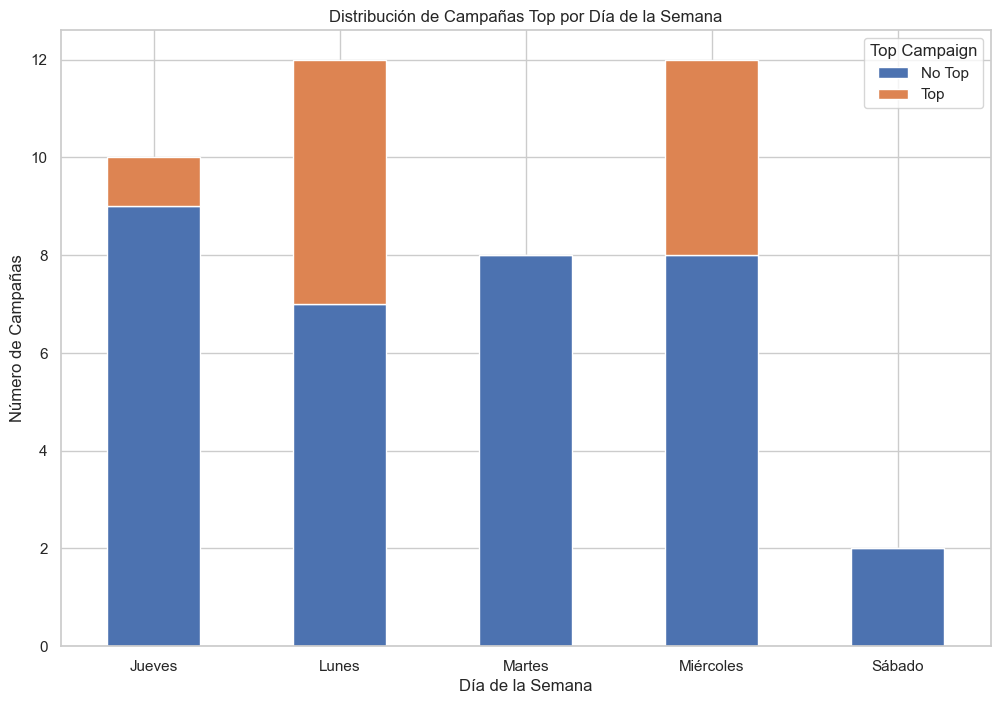

In [95]:
df.groupby(['weekday', 'top_campaign']).size().unstack().fillna(0).plot(kind='bar', stacked=True)
plt.title('Distribución de Campañas Top por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Campañas')
plt.legend(title='Top Campaign', labels=['No Top', 'Top'])
plt.xticks(rotation=0)
plt.show()


In [90]:
kpis_temp_top_campaigns = df.groupby(['top_campaign','tipo_publico'])[['year', 'month', 'weekday']].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
display(kpis_temp_top_campaigns)

,top_campaign,tipo_publico,year,month,weekday
0,0,all,2025,3,Jueves
1,0,artistas,2025,11,Martes
2,0,programadores,2025,1,Lunes
3,1,artistas,2025,10,Lunes


## 📅 Impacto del día de envío en el rendimiento

- **Lunes** concentra la mayor proporción de campañas top, siendo el día más efectivo para envíos.
- **Miércoles** también muestra buen rendimiento, como alternativa viable.
- **Martes y jueves** presentan alto volumen de campañas pero bajo rendimiento relativo.
- **Sábado** no registra campañas de alto rendimiento.

👉 Insight clave:
El éxito no depende solo del volumen de envíos, sino del momento elegido. 
El inicio de semana maximiza la probabilidad de conversión.

### 3. Análisis por Temática del Asunto

Detectamos keywords en los asuntos para entender qué temas traccionan mejor.

In [79]:
keywords = {
    'convocatoria': ['convocatoria', 'abiertas', 'plazo'],
    'webinar_formacion': ['webinar', 'demo', 'taller', 'programa'],
    'evento_feria': ['feria', 'mercartes', 'madferia', 'dferia'],
    'registro_plataforma': ['registro', 'completa', 'perfil'],
    'descubrimiento': ['descubre', 'descobreix', 'artistas', 'destacado']
}

import re

def detectar_tematica(subject):
    subject = str(subject).lower()
    for theme, terms in keywords.items():
        if any(re.search(rf"\b{term}\b", subject) for term in terms):
            return theme
    return 'otros'

df['tematica_asunto'] = df['subject'].apply(detectar_tematica)

tematica_stats = df.groupby(['tematica_asunto', 'tipo_publico'])[['click_rate','trackable_open_rate']].mean().sort_values('click_rate', ascending=False)
tematica_stats

,,click_rate,trackable_open_rate
tematica_asunto,tipo_publico,,
convocatoria,artistas,48.370000,100.000000
otros,artistas,34.073571,91.716429
webinar_formacion,artistas,16.277143,86.928571
descubrimiento,programadores,5.622000,30.120000
otros,programadores,5.315000,49.425000
descubrimiento,artistas,3.640000,67.270000
evento_feria,all,2.247500,70.392500
webinar_formacion,programadores,2.097143,20.018571
evento_feria,artistas,1.770000,59.210000


## 🔍 Insights clave: Temática + Público

### 🏆 Convocatorias → el contenido más efectivo
- Artistas:
  - CTR: 48.37%
  - Open rate: 100%

👉 Insight:
Las convocatorias son el contenido con **mayor capacidad de conversión**.

💡 Funcionan porque:
- ofrecen oportunidad directa
- tienen un CTA claro
- están alineadas con necesidades profesionales

---

### 👩‍🎨 Artistas → público altamente reactivo

- Alto rendimiento en:
  - convocatorias
  - otros (CTR 34%)
  - formación (CTR 16%)

👉 Insight:
El público artista:
- abre mucho
- hace clic
- responde a contenido profesional y formativo

---

### 🏢 Programadores → bajo engagement generalizado

- CTR muy bajo en todas las temáticas:
  - descubrimiento: ~5.6%
  - otros: ~5.3%
  - formación: ~2%

- Open rate bajo (20%–49%)

👉 Insight:
El público programador:
- no está bien impactado
- o no encuentra valor en el contenido

⚠️ Problema estratégico claro

---

### 🎓 Formación / webinar → interés medio, conversión baja

- Artistas:
  - Open alto (~87%)
  - CTR medio (~16%)

- Programadores:
  - Open muy bajo (~20%)
  - CTR muy bajo (~2%)

👉 Insight:
La formación:
- genera interés (abre)
- pero no convierte bien

💡 Necesita mejor CTA o propuesta de valor

---

### 🔍 Descubrimiento → bajo rendimiento

- Artistas:
  - CTR: 3.6%
- Programadores:
  - CTR: 5.6%

👉 Insight:
Contenido exploratorio:
- no activa acción
- baja intención

---

### 🎪 Eventos / ferias → el peor rendimiento

- CTR muy bajo en todos los públicos:
  - <2% en muchos casos

👉 Insight:
Este tipo de contenido:
- no genera interés suficiente
- no activa acción

---

## 🚀 Conclusión estratégica

El rendimiento depende principalmente de:

### 1. 🎯 Tipo de contenido
- Convocatorias → alto rendimiento
- Formación → interés medio
- Eventos / descubrimiento → bajo impacto

### 2. 👥 Público
- Artistas → alto engagement
- Programadores → bajo engagement

---

## 💡 Insight clave global

👉 El éxito no depende solo del contenido,  
sino de la **alineación entre contenido y público**.

---

## 🔥 Recomendaciones

- Priorizar convocatorias para artistas
- Optimizar formación (mejor CTA)
- Reducir contenido de eventos / ferias
- Redefinir estrategia para programadores:
  - mensaje
  - propuesta de valor
  - segmentación

### 4. Visualización Estratégica

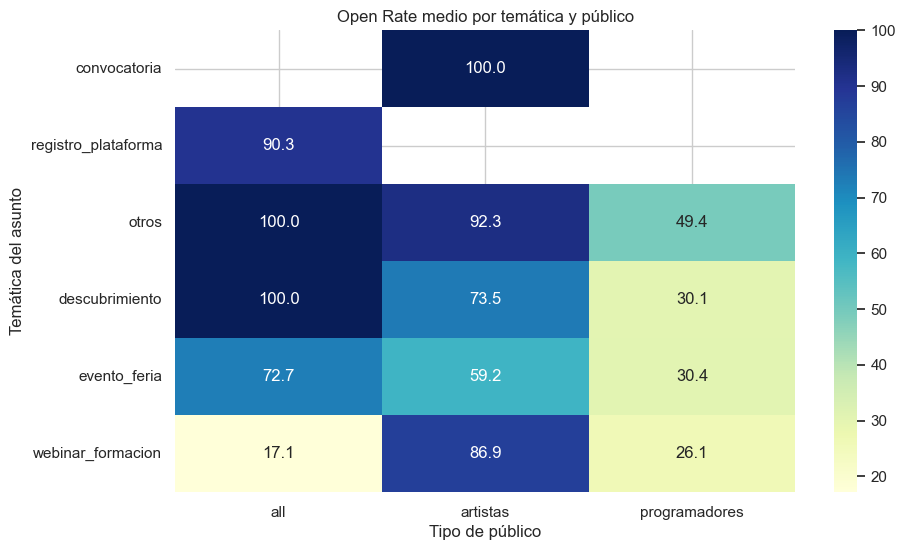

In [65]:
plt.figure(figsize=(10, 6))

# 1. Crear tabla dinámica
pivot_tematica = df.pivot_table(
    values='trackable_open_rate',
    index='tematica_asunto',
    columns='tipo_publico',
    aggfunc='mean'
)

# 2. Ordenar las filas por la media total de open rate
pivot_tematica = pivot_tematica.loc[
    pivot_tematica.mean(axis=1).sort_values(ascending=False).index
]

# 3. Dibujar heatmap
sns.heatmap(pivot_tematica, annot=True, cmap='YlGnBu', fmt=".1f")

plt.title('Open Rate medio por temática y público')
plt.xlabel('Tipo de público')
plt.ylabel('Temática del asunto')
plt.show()

### 4. Insights Principales

1. **Dominio de Convocatorias:** El público 'artistas' responde significativamente mejor a las 'convocatorias' con un Open Rate medio de ~88%.
2. **Interés Temático:** La temática 'convocatoria' es la que genera mayor interés inicial (Open Rate: ~92%).
3. **Segmento Programadores:** Los envíos a 'programadores' tienen un rendimiento crítico (~30% OR), indicando falta de relevancia en el asunto o el momento del envío.
4. **Benchmark:** Se han identificado 12 campañas 'Top Performance' que deben servir de base para futuros diseños.